Research question:
"How can k-means clustering techniques uncover patterns among patients who are readmitted to the hospital based on their health and hospitalization data?"

In [1]:
#Importing libraries
import pandas as pd
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
#Loading the dataset
medical_clean = pd.read_csv('medical_clean_D212.csv')

In [65]:
#Information about the dataset
medical_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

In [66]:
#Selecting variables to be used for the algorithm
variables = ['Initial_days', 'Doc_visits', 'Age', 'ReAdmis', 'Overweight']
df = medical_clean[variables].copy()

In [67]:
#Checking for duplicate values
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool


In [68]:
#Checking for missing values
print(df.isnull().sum())

Initial_days    0
Doc_visits      0
Age             0
ReAdmis         0
Overweight      0
dtype: int64


In [69]:
#List of numerical columns for checking outliers
numerical_columns = ['Initial_days', 'Doc_visits', 'Age']

#Identify outliers based on Z-scores
z_scores = np.abs(zscore(df[numerical_columns]))
z_score_outliers = (z_scores > 3).sum(axis=0)
print("Outliers based on Z-score method:")
print(z_score_outliers)

Outliers based on Z-score method:
Initial_days    0
Doc_visits      8
Age             0
dtype: int64


<Axes: xlabel='Doc_visits'>

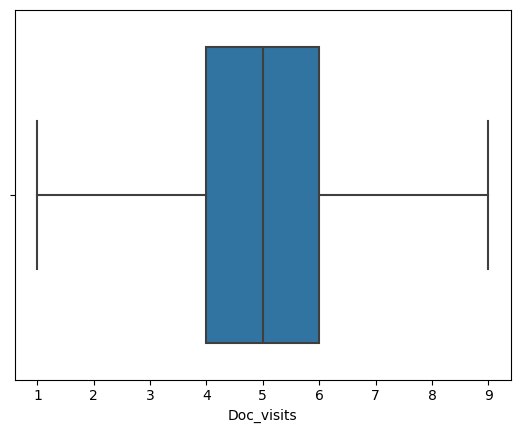

In [70]:
#Checking for outliers for Doc_visits
sns.boxplot(x = 'Doc_visits', data = df)

In [71]:
#Converting categorical variable Readmis to a numeric variable
df['ReAdmis'] = df['ReAdmis'].map({'Yes': 1, 'No': 0})

In [72]:
#Converting categorical variable Overweight to a numeric variable
df['Overweight'] = df['Overweight'].map({'Yes': 1, 'No': 0})

In [73]:
#Feature scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [74]:
#Determining optimal number of clusters
inertia = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, kmeans.labels_))

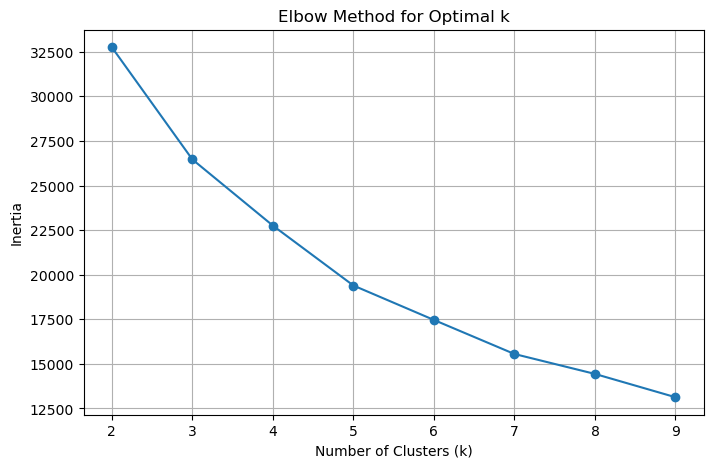

In [75]:
#Plot elbow method
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

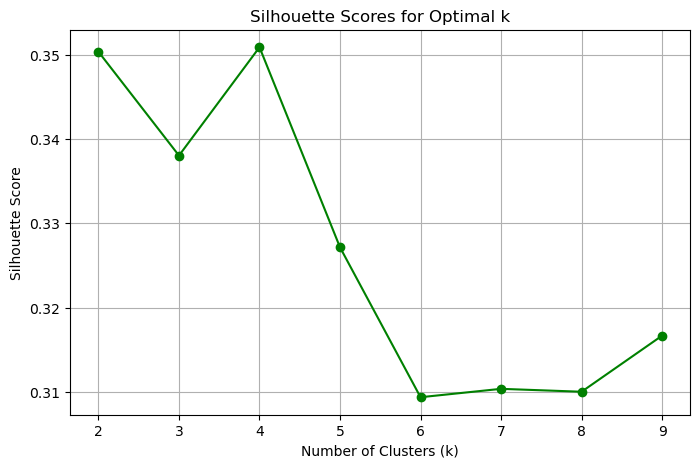

In [76]:
#Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Scores for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid()
plt.show()

In [77]:
#Apply K-Means with optimal K
optimal_k = 3  # Select based on Elbow and Silhouette analysis
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(scaled_data)

In [78]:
#Adding cluster labels to the dataset
df['Cluster'] = clusters

In [79]:
#Cluster analysis
cluster_summary = df.groupby('Cluster').mean()
print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
         Initial_days  Doc_visits        Age  ReAdmis  Overweight
Cluster                                                          
0           63.859507    5.012537  53.940311      1.0    0.704279
1           17.718595    5.002746  53.209226      0.0    0.000000
2           17.291996    5.015743  53.285144      0.0    1.000000


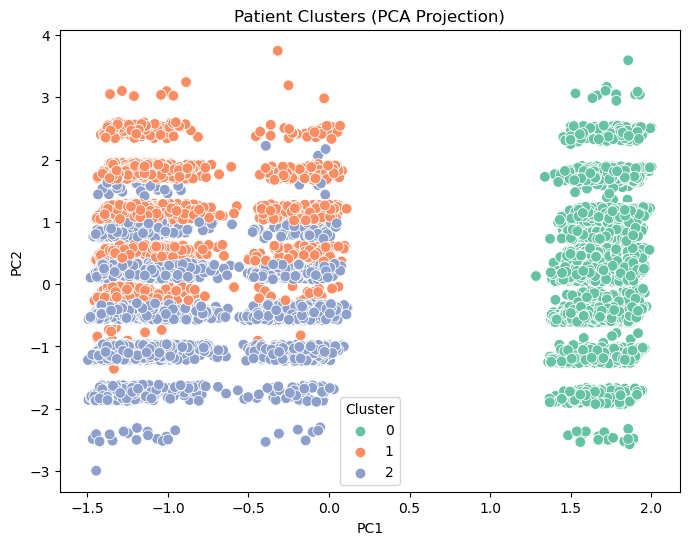

In [80]:
#Cluster visuaization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=60)
plt.title('Patient Clusters (PCA Projection)')
plt.show()


In [81]:
#Save cleaned dataset
new_data_path = 'output/new_medical_data_kmeans_clusters_D212_I.csv'
df.to_csv(new_data_path, index=False)